In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load dataset
df= pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [2]:
# Checking sample data
df.head(20)


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0,na,na
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3,na,na
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1,na,na
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.4,1,2,48,98,23,46.9,48,98
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,9,17.6,42,82.4,33,64.7,40,78.4


In [3]:
# Check columns in dataset
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [4]:
# Converts data in numeric and puts "NaN" to non numeric value
df["Mean Score"] = pd.to_numeric(df["Mean Score"], errors="coerce")

# Removes raw with value "NaN"
df_cleandata = df.dropna(subset=["Mean Score"])

In [5]:
# Filter for one school 25Q525
school_df = df[df['School DBN'] == '25Q525']


# Selecting columns of interest
school_df[['School DBN', 'Regents Exam', 'Mean Score']]

,School DBN,Regents Exam,Mean Score
14321,25Q525,Algebra2/Trigonometry,90.7
14322,25Q525,Algebra2/Trigonometry,93.6
14323,25Q525,Common Core Algebra,78.0
14324,25Q525,Common Core Algebra,88.7
14325,25Q525,Common Core Algebra,89.7
...,...,...,...
193186,25Q525,U.S. History and Government,96.5
193187,25Q525,U.S. History and Government,90.5
193188,25Q525,U.S. History and Government,96.0
193189,25Q525,U.S. History and Government,91.8


In [6]:

# Selecting "Common Core Algebra"'s value to a new dataframe called algebra
algebra = df_cleandata[df_cleandata["Regents Exam"] == "Common Core Algebra"]

#For Townsend Harris school
Townsend = algebra[algebra["School DBN"] == "25Q525"]
Townsend_score = Townsend["Mean Score"].mean()

# NYC-wide stats
nyc_score = algebra["Mean Score"].mean()


Townsend_score, nyc_score


(np.float64(85.53333333333333), np.float64(67.4897181441506))

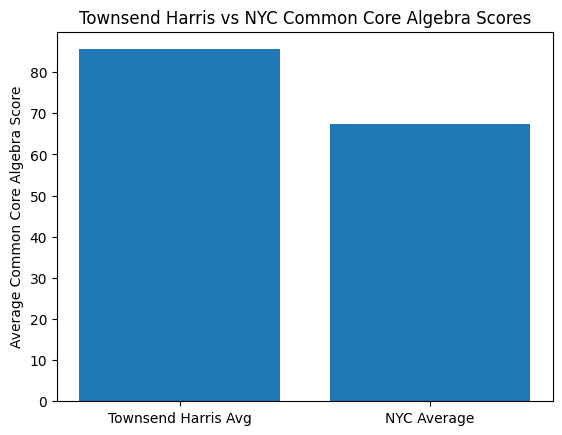

In [8]:
labels = ["Townsend Harris Avg", "NYC Average"]
scores = [Townsend_score, nyc_score]

plt.bar(labels, scores)
plt.ylabel("Average Common Core Algebra Score")
plt.title("Townsend Harris vs NYC Common Core Algebra Scores")
plt.show()

In [ ]:
# Townsend Harris School’s average Algebra common core score is higher than the average score for all NYC schools in the dataset.
# This suggests that students at Townsend Harris School perform better on this exam compared with many other schools in NYC.